In [10]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from scipy.stats import norm
import nbimporter

In [15]:
#data = [df_fits, 
        #all_J,
        #bulge_J  
        #RC_J_seen, 
        #RC_J_I_seen, 
        #RC_J_I_V_seen, 
        #pop_filter(RC_J_seen)[0], # resolved Red clump with J < 19 from the thin disk
        #pop_filter(RC_J_seen)[1], # resolved Red clump with J < 19 from the bulge
        #pop_filter(RC_J_I_seen)[0], # resolved Red clump with J < 19 and I < 21 from the thin disk
        #pop_filter(RC_J_I_seen)[1] # resolved Red clump with J < 19 and I < 21 from the bulge
        #RC
        #]

all_star = joblib.load('data_0.joblib')
all_J = joblib.load('data_1.joblib')
bulge_J = joblib.load('data_2.joblib')
RC_J_seen = joblib.load('data_3.joblib')
RC_J_I_seen = joblib.load('data_4.joblib')
RC_J_thin_seen = joblib.load('data_6.joblib')
RC_J_bulge_seen = joblib.load('data_7.joblib')
RC_J_I_thin_seen = joblib.load('data_8.joblib')
RC_J_I_bulge_seen = joblib.load('data_9.joblib')
RC = joblib.load('data_10.joblib')

In [12]:
import nbimporter
from Selection_of_RED_CLUMP import pop_filter


In [16]:
thin_disk = pop_filter(all_star)[0]

# ROTATION CURVE with POLYNOMIAL FIT

Now, let's compute the rotation curve of the RC seen with J < 19 and I < 21, for the bulge and for the thin disk.

Per comodità, definisco qui la funzione per il calcolo dei coefficienti del polinomio interpolatore di grado n

In [38]:
def fit(df, n):
    # Raggrupo le stelle con stessa distanza e calcolo la media delle rispettive V_phi
    avgV_phi = df.groupby("R")["V_phi"].mean()

    # Mi creo due vettori con tutti i raggi presi una sola volta. Tale vettore dovrebbe avere la stessa lunghezza del vettore contenente le velocità
    # V_phi medie.
    unique_R = np.unique(df["R"])

    # Creo un fit con polinomio di grado n
    coefficienti_del_fit = np.polyfit(unique_R, avgV_phi, deg=n)
    y_fit = np.poly1d(coefficienti_del_fit) # funzione che ritorna la funzione del polinomio di grado n fittato 

    return unique_R, y_fit(unique_R)

In [39]:
def fit_V_R(df, n):
    # Raggrupo le stelle con stessa distanza e calcolo la media delle rispettive V_R
    avgV_R = df.groupby("R")["V_R"].mean()

    # Mi creo due vettori con tutti i raggi presi una sola volta. Tale vettore dovrebbe avere la stessa lunghezza del vettore contenente le velocità
    # V_R medie.
    unique_R = np.unique(df["R"])

    # Creo un fit con polinomio di grado n
    coefficienti_del_fit = np.polyfit(unique_R, avgV_R, deg=n)
    y_fit = np.poly1d(coefficienti_del_fit)

    return unique_R, y_fit(unique_R)

R vs V_phi for the RC with J < 19 not covered by luminous near stars. 

C:\Users\franc\AppData\Local\Temp\ipykernel_17836\2566134438.py:10: RankWarning: Polyfit may be poorly conditioned
  coefficienti_del_fit = np.polyfit(unique_R, avgV_phi, deg=n)
C:\Users\franc\AppData\Local\Temp\ipykernel_17836\2566134438.py:10: RankWarning: Polyfit may be poorly conditioned
  coefficienti_del_fit = np.polyfit(unique_R, avgV_phi, deg=n)


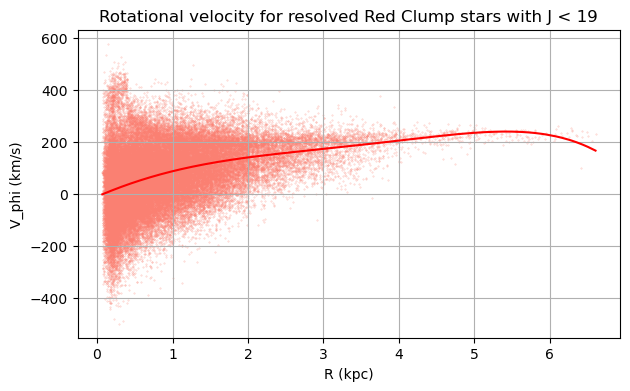

In [40]:
# Plot the data
plt.figure(figsize=(7,4))
plt.plot(fit(RC_J_seen, 5)[0], fit(RC_J_seen, 5)[1], label='RC J < 19', color='red')
plt.scatter(RC_J_seen["R"], RC_J_seen["V_phi"], s=0.1, color='salmon', alpha=0.5, label='RC J < 19')
plt.xlabel("R (kpc)")
plt.ylabel("V_phi (km/s)")
plt.title("Rotational velocity for resolved Red Clump stars with J < 19")
#plt.legend()
plt.grid(True)
plt.show()

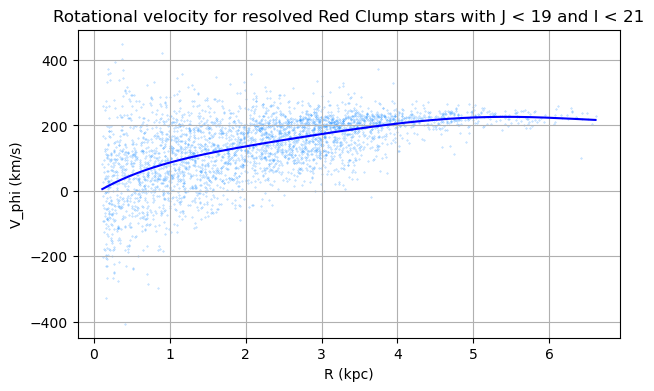

In [41]:
# Plot the data
plt.figure(figsize=(7, 4))
plt.plot(fit(RC_J_I_seen, 5)[0], fit(RC_J_I_seen, 5)[1], color="blue", label="Curva interpolatoria (grado = 5)")
plt.scatter(RC_J_I_seen["R"], RC_J_I_seen["V_phi"], s = 0.1 , alpha = 0.5, color="dodgerblue")
plt.xlabel("R (kpc)")
plt.ylabel("V_phi (km/s)")
plt.title("Rotational velocity for resolved Red Clump stars with J < 19 and I < 21")
#plt.legend()
plt.grid(True)
plt.show()

Metto insieme i grafici per avere una comprensione più esaustiva dell'andamento della curva con o senza vincolo su I e con tutte le stelle.

C:\Users\franc\AppData\Local\Temp\ipykernel_17836\2566134438.py:10: RankWarning: Polyfit may be poorly conditioned
  coefficienti_del_fit = np.polyfit(unique_R, avgV_phi, deg=n)
C:\Users\franc\AppData\Local\Temp\ipykernel_17836\2566134438.py:10: RankWarning: Polyfit may be poorly conditioned
  coefficienti_del_fit = np.polyfit(unique_R, avgV_phi, deg=n)
C:\Users\franc\AppData\Local\Temp\ipykernel_17836\2566134438.py:10: RankWarning: Polyfit may be poorly conditioned
  coefficienti_del_fit = np.polyfit(unique_R, avgV_phi, deg=n)
C:\Users\franc\AppData\Local\Temp\ipykernel_17836\2566134438.py:10: RankWarning: Polyfit may be poorly conditioned
  coefficienti_del_fit = np.polyfit(unique_R, avgV_phi, deg=n)


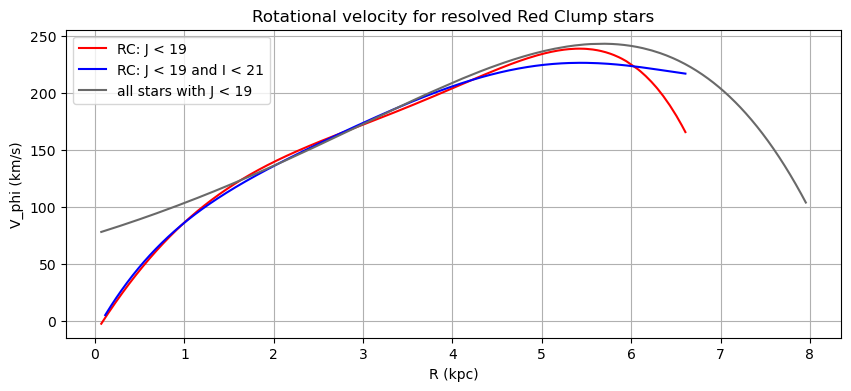

In [42]:
# Plot the data and the curves together

plt.figure(figsize=(10, 4))
plt.plot(fit(RC_J_seen, 5)[0], fit(RC_J_seen, 5)[1], label='RC: J < 19', color='red')
plt.plot(fit(RC_J_I_seen, 5)[0], fit(RC_J_I_seen, 5)[1], color="blue", label="RC: J < 19 and I < 21")
plt.plot(fit(all_J, 5)[0], fit(all_J, 5)[1], color="dimgrey", label="all stars with J < 19")
plt.xlabel("R (kpc)")
plt.ylabel("V_phi (km/s)")
plt.title("Rotational velocity for resolved Red Clump stars")
plt.legend()
plt.grid(True)
plt.show()

C:\Users\franc\AppData\Local\Temp\ipykernel_17836\2566134438.py:10: RankWarning: Polyfit may be poorly conditioned
  coefficienti_del_fit = np.polyfit(unique_R, avgV_phi, deg=n)
C:\Users\franc\AppData\Local\Temp\ipykernel_17836\2566134438.py:10: RankWarning: Polyfit may be poorly conditioned
  coefficienti_del_fit = np.polyfit(unique_R, avgV_phi, deg=n)


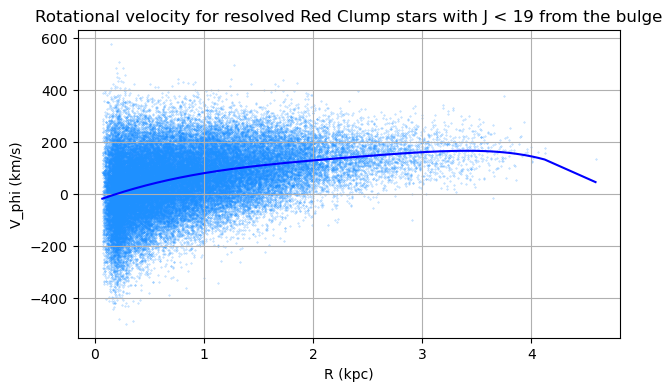

In [43]:
# Plot the data
plt.figure(figsize=(7, 4))
plt.plot(fit(RC_J_bulge_seen, 5)[0], fit(RC_J_bulge_seen, 5)[1], color="blue", label="RC from bulge with J < 19")
plt.scatter(RC_J_bulge_seen["R"], RC_J_bulge_seen["V_phi"], s = 0.1 , alpha = 0.5, color="dodgerblue")
plt.xlabel("R (kpc)")
plt.ylabel("V_phi (km/s)")
plt.title("Rotational velocity for resolved Red Clump stars with J < 19 from the bulge")
#plt.legend()
plt.grid(True)
plt.show()

C:\Users\franc\AppData\Local\Temp\ipykernel_17836\2566134438.py:10: RankWarning: Polyfit may be poorly conditioned
  coefficienti_del_fit = np.polyfit(unique_R, avgV_phi, deg=n)
C:\Users\franc\AppData\Local\Temp\ipykernel_17836\2566134438.py:10: RankWarning: Polyfit may be poorly conditioned
  coefficienti_del_fit = np.polyfit(unique_R, avgV_phi, deg=n)


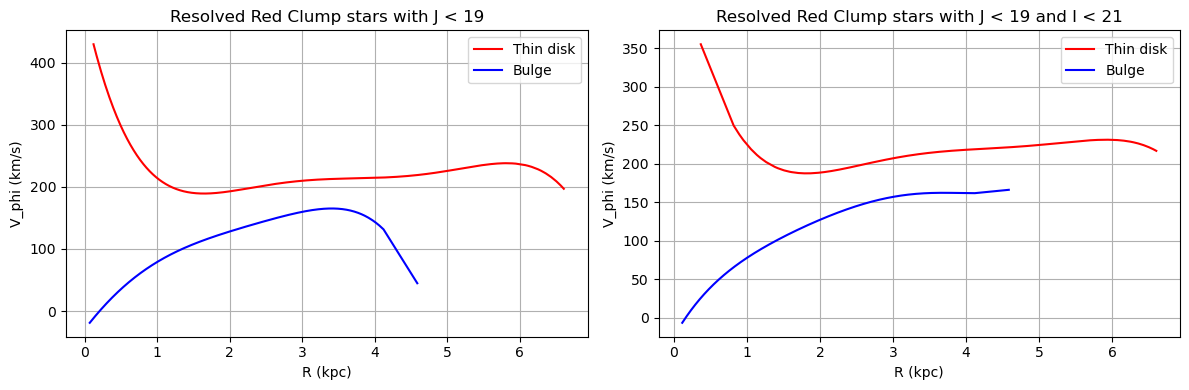

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(fit(RC_J_thin_seen, 5)[0], fit(RC_J_thin_seen, 5)[1], label='Thin disk', color='red')
axes[0].plot(fit(RC_J_bulge_seen, 5)[0], fit(RC_J_bulge_seen, 5)[1], label='Bulge', color='blue')
axes[0].set_xlabel("R (kpc)")
axes[0].set_ylabel("V_phi (km/s)")
axes[0].set_title("Resolved Red Clump stars with J < 19")
axes[0].grid(True)
axes[0].legend()

axes[1].plot(fit(RC_J_I_thin_seen, 5)[0], fit(RC_J_I_thin_seen, 5)[1], label='Thin disk', color='red')
axes[1].plot(fit(RC_J_I_bulge_seen, 5)[0], fit(RC_J_I_bulge_seen, 5)[1], label='Bulge', color='blue')
axes[1].set_xlabel("R (kpc)")
axes[1].set_ylabel("V_phi (km/s)")
axes[1].set_title("Resolved Red Clump stars with J < 19 and I < 21")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


E ora calcoliamo il plot per la velocità radiale cilindrica V_R

C:\Users\franc\AppData\Local\Temp\ipykernel_17836\852860517.py:10: RankWarning: Polyfit may be poorly conditioned
  coefficienti_del_fit = np.polyfit(unique_R, avgV_R, deg=n)
C:\Users\franc\AppData\Local\Temp\ipykernel_17836\852860517.py:10: RankWarning: Polyfit may be poorly conditioned
  coefficienti_del_fit = np.polyfit(unique_R, avgV_R, deg=n)


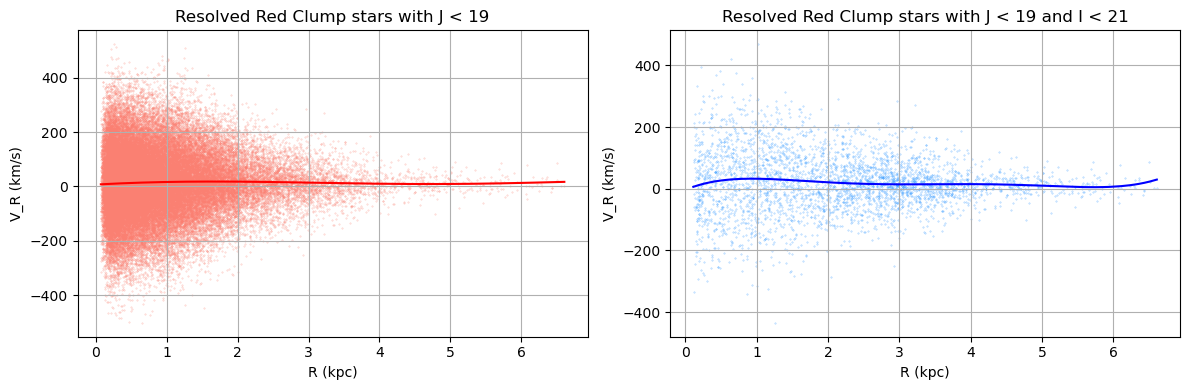

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(fit_V_R(RC_J_seen, 5)[0], fit_V_R(RC_J_seen, 5)[1], label='J < 19', color='red')
axes[0].scatter(RC_J_seen["R"], RC_J_seen["V_R"], s=0.1, color='salmon', alpha=0.5, label='RC J < 19')
axes[0].set_xlabel("R (kpc)")
axes[0].set_ylabel("V_R (km/s)")
axes[0].set_title("Resolved Red Clump stars with J < 19")
axes[0].grid(True)
#axes[0].legend()

axes[1].plot(fit_V_R(RC_J_I_seen, 5)[0], fit_V_R(RC_J_I_seen, 5)[1], label='J < 19', color='blue')
axes[1].scatter(RC_J_I_seen["R"], RC_J_I_seen["V_R"], s=0.1, color='dodgerblue', alpha=0.5, label='RC J < 19')
axes[1].set_xlabel("R (kpc)")
axes[1].set_ylabel("V_R (km/s)")
axes[1].set_title("Resolved Red Clump stars with J < 19 and I < 21")
axes[1].grid(True)
#axes[1].legend()

plt.tight_layout()
plt.show()

# ROTATION CURVE with MEDIAN and MEAN LINE.

Until now we fit our data with a polynomial of degree 5 but, apart from the poorly conditioned warning, we get also a curve that may not well represent the data.
Let's change this with the median which is the median value over a certain amount of data (bin), connected together among all the data.
Furthermore, let's calculate the 4 possible errors/uncertainty: confidence interval, standard deviation, standard error of the mean and percentile interval.

In [18]:
def median_with_errors(df, x, y, bins, scatter, error_type, confidence, color1, color2, label=None):
    """
    Plot scatter data (optional), median line, and error bars for binned data.

    Parameters:
        df: pandas.DataFrame
        x: str, column name for x axis
        y: str, column name for y axis
        bins: int, number of bins
        scatter: bool, whether to plot scatter data
        error_type: str, one of ['ci', 'std', 'sem', 'pi'] 
        (Confidence interval, standard deviation, standard error of the mean, or percentile interval)
        confidence: float, confidence level for CI/PI
        color1 & 2: str, color for median/error bars and scatter points
        label: str, label for the median line
    """
    xvals = df[x].values
    yvals = df[y].values
    bin_edges = np.linspace(np.nanmin(xvals), np.nanmax(xvals), bins + 1)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    medians = []
    errors_lower = []
    errors_upper = []

    for i in range(bins):
        mask = (xvals >= bin_edges[i]) & (xvals < bin_edges[i+1])
        ybin = yvals[mask]
        if len(ybin) == 0:
            medians.append(np.nan)
            errors_lower.append(np.nan)
            errors_upper.append(np.nan)
            continue
        med = np.nanmedian(ybin)
        medians.append(med)
        if error_type == 'std':
            err = np.nanstd(ybin)
            errors_lower.append(err)
            errors_upper.append(err)
        elif error_type == 'SE':
            err = 1.253 * np.nanstd(ybin) / np.sqrt(len(ybin))
            errors_lower.append(err)
            errors_upper.append(err)
        elif error_type == 'ci':
            # Bootstrap confidence interval for the median
            boot_samples = [np.nanmedian(np.random.choice(ybin, size=len(ybin), replace=True)) for _ in range(1000)]
            lower = np.percentile(boot_samples, (1-confidence)/2*100)
            upper = np.percentile(boot_samples, (1+confidence)/2*100)
            errors_lower.append(med - lower)
            errors_upper.append(upper - med)
        elif error_type == 'pi':
            # Percentile interval
            lower, upper = np.percentile(ybin, [(1-confidence)/2*100, (1+confidence)/2*100])
            #upper = np.percentile(ybin, (1+confidence)/2*100)
            errors_lower.append(med - lower)
            errors_upper.append(upper - med)
        else:
            errors_lower.append(np.nan)
            errors_upper.append(np.nan)

    if scatter == True:
        plt.scatter(xvals, yvals, s=1, alpha=0.3, color=color1, label='Data')
    plt.errorbar(bin_centers, medians, yerr=[errors_lower, errors_upper], fmt='-o', color=color2, capsize=3, label=label)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(True)
    plt.legend()
    #plt.show()

In [47]:
def mean_with_errors(df, x, y, bins, scatter, error_type, confidence, color1, color2, label=None):
    """
    Plot scatter data (optional), mean line, and error bars for binned data.

    Parameters:
        df: pandas.DataFrame
        x: str, column name for x axis
        y: str, column name for y axis
        bins: int, number of bins
        scatter: bool, whether to plot scatter data
        error_type: str, one of ['ci', 'std', 'sem', 'pi'] 
        (Confidence interval, standard deviation, standard error of the mean, or percentile interval)
        confidence: float, confidence level for CI/PI
        color1 & 2: str, color for median/error bars and scatter points
        label: str, label for the median line
    """
    xvals = df[x].values
    yvals = df[y].values
    bin_edges = np.linspace(np.nanmin(xvals), np.nanmax(xvals), bins + 1)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])
    means = []
    errors_lower = []
    errors_upper = []

    for i in range(bins):
        mask = (xvals >= bin_edges[i]) & (xvals < bin_edges[i+1])
        ybin = yvals[mask]
        if len(ybin) == 0:
            mean.append(np.nan)
            errors_lower.append(np.nan)
            errors_upper.append(np.nan)
            continue
        mean = np.nanmean(ybin)
        means.append(mean)
        if error_type == 'std':
            err = np.nanstd(ybin)
            errors_lower.append(err)
            errors_upper.append(err)
        elif error_type == 'SE':
            err = 1.253 * np.nanstd(ybin) / np.sqrt(len(ybin))
            errors_lower.append(err)
            errors_upper.append(err)
        elif error_type == 'ci':
            # Bootstrap confidence interval for the median
            boot_samples = [np.nanmean(np.random.choice(ybin, size=len(ybin), replace=True)) for _ in range(1000)]
            lower = np.percentile(boot_samples, (1-confidence)/2*100)
            upper = np.percentile(boot_samples, (1+confidence)/2*100)
            errors_lower.append(mean - lower)
            errors_upper.append(upper - mean)
        elif error_type == 'pi':
            # Percentile interval
            lower, upper = np.percentile(ybin, [(1-confidence)/2*100, (1+confidence)/2*100])
            #upper = np.percentile(ybin, (1+confidence)/2*100)
            errors_lower.append(mean - lower)
            errors_upper.append(upper - mean)
        else:
            errors_lower.append(np.nan)
            errors_upper.append(np.nan)

    if scatter == True:
        plt.scatter(xvals, yvals, s=0.2, alpha=0.3, color=color1, label='Data')
    plt.errorbar(bin_centers, means, yerr=[errors_lower, errors_upper], fmt='-o', color=color2, capsize=3, label=label)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.grid(True)
    plt.legend()
    #plt.show()

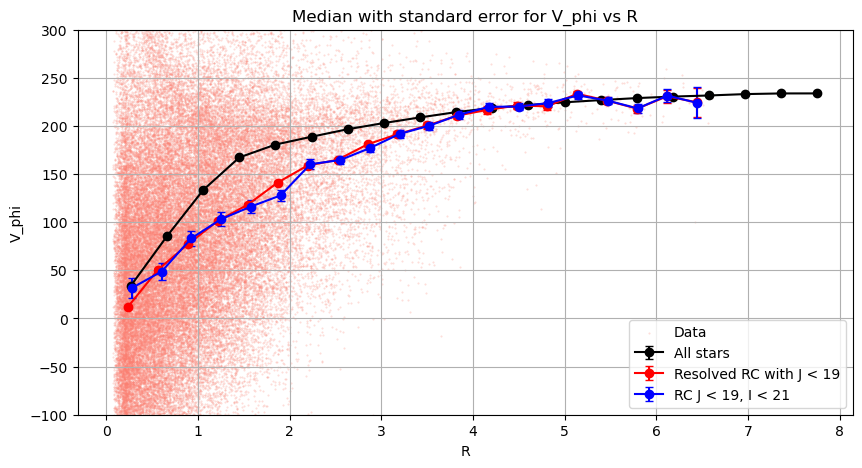

In [48]:
plt.figure(figsize=(10, 5))
plt.ylim(-100, 300)
plt.title("Median with standard error for V_phi vs R")
median_with_errors(all_star, 'R', 'V_phi', bins=20, scatter=False, error_type='SE', confidence=0.85, color1="salmon", color2='black', label='All stars')
median_with_errors(RC_J_seen, 'R', 'V_phi', bins=20, scatter=True, error_type='SE', confidence=0.85, color1="salmon", color2='red', label='Resolved RC with J < 19')
median_with_errors(RC_J_I_seen, 'R', 'V_phi', bins=20, scatter=False, error_type='SE', confidence=0.85, color1="dodgerblue", color2='blue', label='RC J < 19, I < 21')

Now, only for stars form the bulge and thin disk.

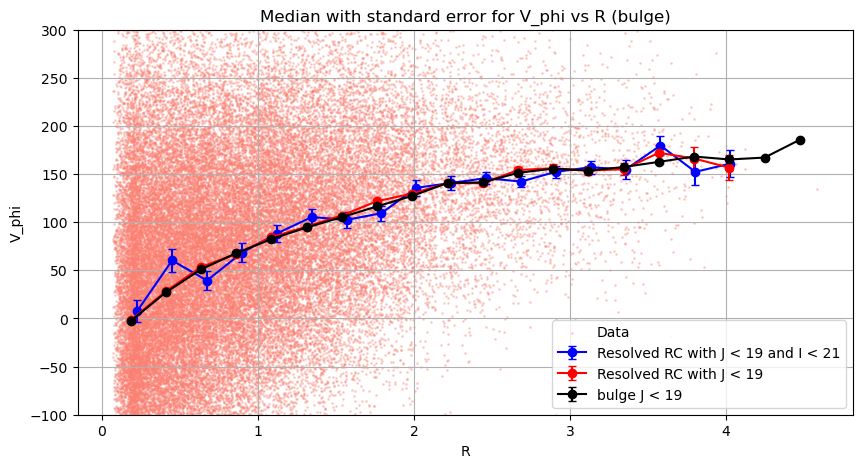

In [65]:
# BULGE

plt.figure(figsize=(10, 5))
plt.ylim(-100, 300)
plt.title("Median with standard error for V_phi vs R (bulge)")
median_with_errors(RC_J_I_bulge_seen, 'R', 'V_phi', bins=20, scatter=False, error_type='SE', confidence=0.85, color1="dodgerblue", color2='blue', label='Resolved RC with J < 19 and I < 21')
median_with_errors(RC_J_bulge_seen, 'R', 'V_phi', bins=20, scatter=True, error_type='SE', confidence=0.85, color1="salmon", color2='red', label='Resolved RC with J < 19')
median_with_errors(bulge_J, 'R', 'V_phi', bins=20, scatter=False, error_type='No', confidence=0.85, color1="black", color2='black', label='bulge J < 19')

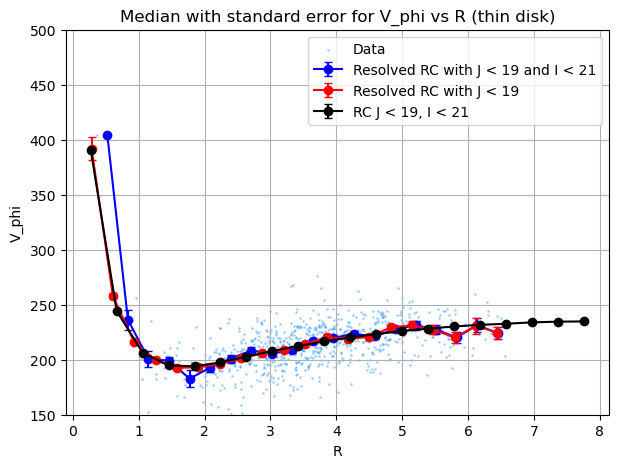

In [20]:
# THIN DISK

plt.figure(figsize=(7, 5))
plt.ylim(150, 500)
plt.title("Median with standard error for V_phi vs R (thin disk)")
median_with_errors(RC_J_I_thin_seen, 'R', 'V_phi', bins=20, scatter=True, error_type='SE', confidence=0.85, color1="dodgerblue", color2='blue', label='Resolved RC with J < 19 and I < 21')
median_with_errors(RC_J_thin_seen, 'R', 'V_phi', bins=20, scatter=False, error_type='SE', confidence=0.85, color1="salmon", color2='red', label='Resolved RC with J < 19')
median_with_errors(thin_disk, 'R', 'V_phi', bins=20, scatter=False, error_type='No', confidence=0.85, color1="salmon", color2='black', label='RC J < 19, I < 21')

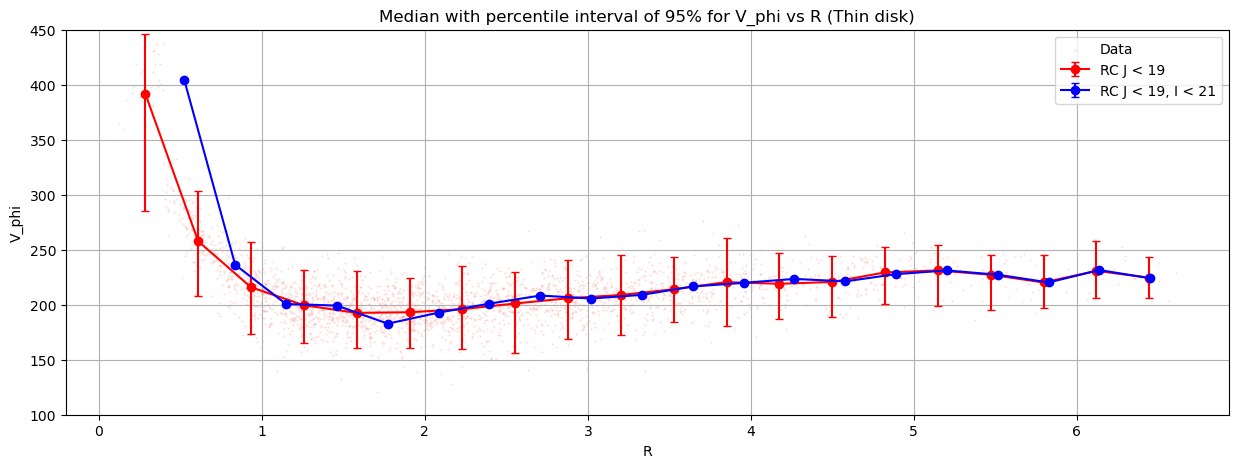

In [51]:
plt.figure(figsize = (15,5))
plt.ylim(100, 450)
plt.title("Median with percentile interval of 95% for V_phi vs R (Thin disk)")
median_with_errors(RC_J_thin_seen, 'R', 'V_phi', bins=20, scatter=True, error_type='pi', confidence=0.95, color1="salmon", color2='red', label='RC J < 19')
median_with_errors(RC_J_I_thin_seen, 'R', 'V_phi', bins=20, scatter=False, error_type='no', confidence=0.95, color1="dodgerblue", color2='blue', label='RC J < 19, I < 21')
#median_fit(RC, "x_Gal", "V_phi", 20, "dodgerblue", "grey", "All stars from the bulge, J < 19", False)

Then, radial velocity V_R.

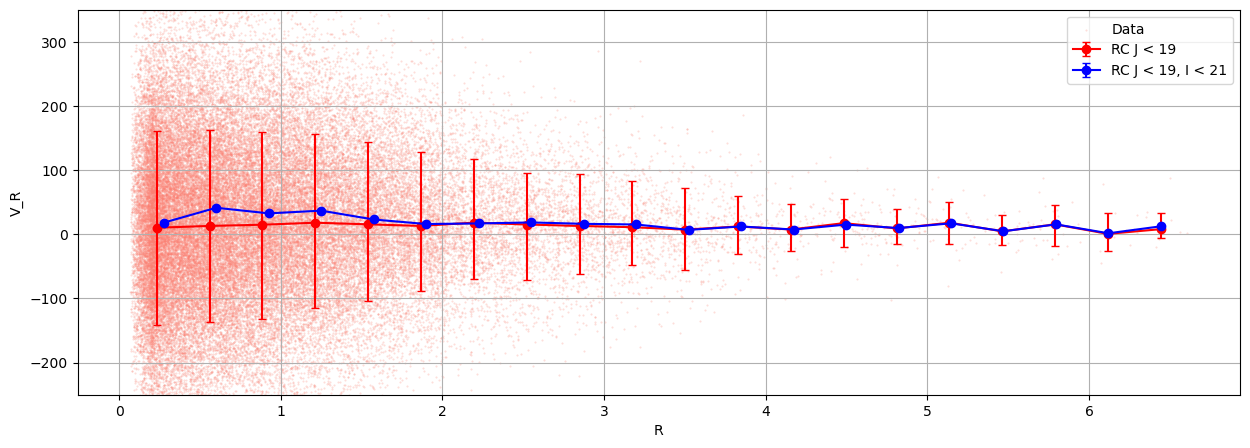

In [52]:
plt.figure(figsize = (15,5))
plt.ylim(-250, 350)
median_with_errors(RC_J_seen, 'R', 'V_R', bins=20, scatter=True, error_type='pi', confidence=0.75, color1="salmon", color2='red', label='RC J < 19')
median_with_errors(RC_J_I_seen, 'R', 'V_R', bins=20, scatter=False, error_type='no', confidence=0.75, color1="dodgerblue", color2='blue', label='RC J < 19, I < 21')
#median_fit(RC, "x_Gal", "V_phi", 20, "dodgerblue", "grey", "All stars from the bulge, J < 19", False)

and radial velocity for the bulge.

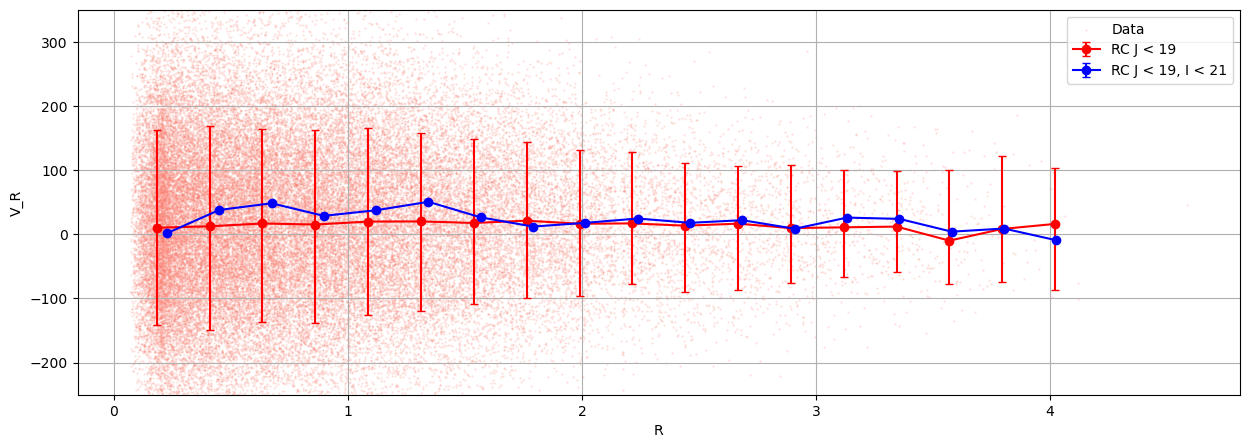

In [53]:
plt.figure(figsize = (15,5))
plt.ylim(-250, 350)
median_with_errors(RC_J_bulge_seen, 'R', 'V_R', bins=20, scatter=True, error_type='pi', confidence=0.75, color1="salmon", color2='red', label='RC J < 19')
median_with_errors(RC_J_I_bulge_seen, 'R', 'V_R', bins=20, scatter=False, error_type='no', confidence=0.75, color1="dodgerblue", color2='blue', label='RC J < 19, I < 21')


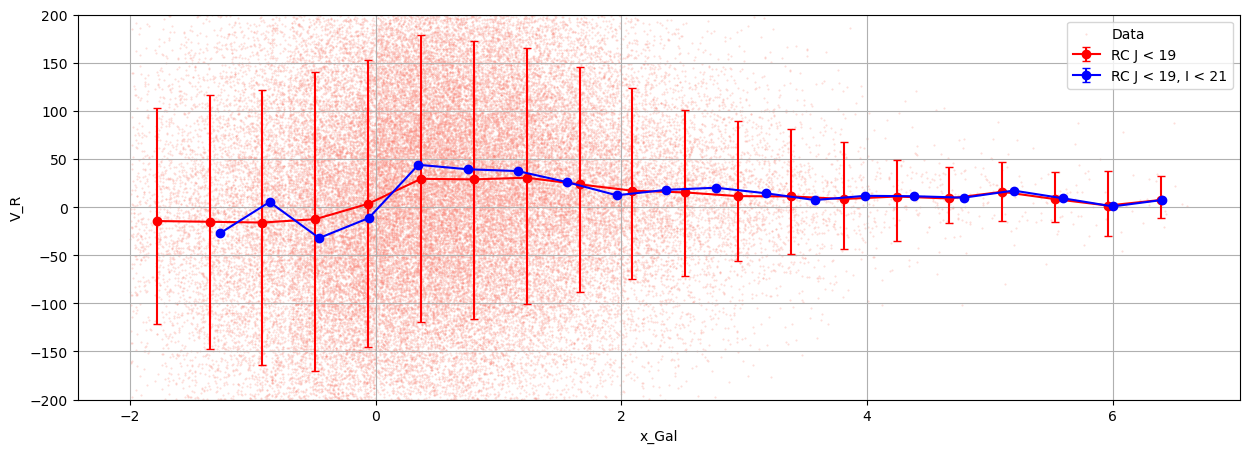

In [54]:
plt.figure(figsize = (15,5))
plt.ylim(-200, 200)
median_with_errors(RC_J_seen, 'x_Gal', 'V_R', bins=20, scatter=True, error_type='pi', confidence=0.75, color1="salmon", color2='red', label='RC J < 19')
median_with_errors(RC_J_I_seen, 'x_Gal', 'V_R', bins=20, scatter=False, error_type='no', confidence=0.75, color1="dodgerblue", color2='blue', label='RC J < 19, I < 21')


In order to notice better what happens near the center of the galaxy, instead of R let's plot x_Gal.

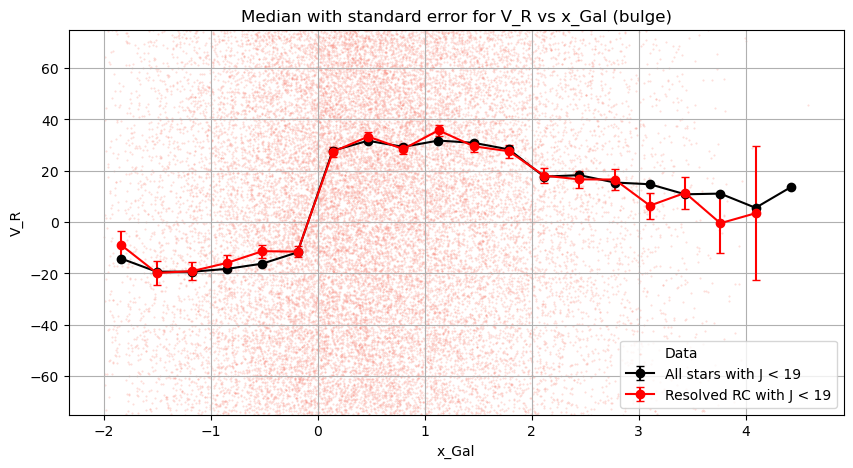

In [55]:
plt.figure(figsize=(10, 5))
plt.ylim(-75, 75)
plt.title("Median with standard error for V_R vs x_Gal (bulge)")
median_with_errors(bulge_J, 'x_Gal', 'V_R', bins=20, scatter=False, error_type='No', confidence=0.85, color1="salmon", color2='black', label='All stars with J < 19')
median_with_errors(RC_J_bulge_seen, 'x_Gal', 'V_R', bins=20, scatter=True, error_type='SE', confidence=0.85, color1="salmon", color2='red', label='Resolved RC with J < 19')

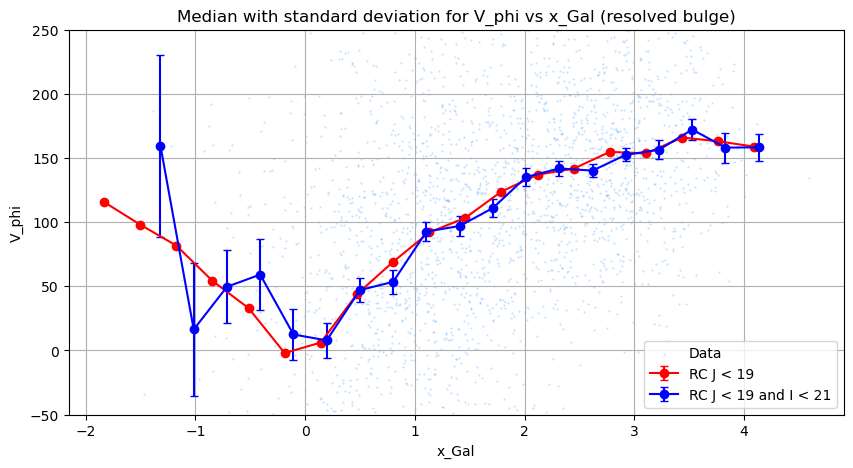

In [56]:
plt.figure(figsize=(10, 5))
plt.ylim(-50, 250)
plt.title("Median with standard deviation for V_phi vs x_Gal (resolved bulge)")
median_with_errors(RC_J_bulge_seen, 'x_Gal', 'V_phi', bins=20, scatter=False, error_type='No', confidence=0.85, color1="salmon", color2='red', label='RC J < 19')
median_with_errors(RC_J_I_bulge_seen, 'x_Gal', 'V_phi', bins=20, scatter=True, error_type='SE', confidence=0.85, color1="dodgerblue", color2='blue', label='RC J < 19 and I < 21')